In [25]:
import numpy as np
import pandas as pd

loinc_rank_matrix = pd.read_csv("prs_incrementalr2_matrix_260225_loinccode_rankmatrix.csv")
loinc_rank_matrix = loinc_rank_matrix.set_index("trait")
icd_rank_matrix = pd.read_csv("../aou_icd_260217/prs_adjauc_matrix_260217_rootcode_rankmatrix.csv")
icd_rank_matrix = icd_rank_matrix.set_index("trait")

In [26]:
def ranking_row_to_series(row):
    pgs = row.dropna().astype(str)
    pgs = pgs.str.split("__").str[-1]
    ranks = np.arange(1, len(pgs) + 1)
    return pd.Series(ranks, index=pgs.values)

loinc_rank_dict = {
    trait: ranking_row_to_series(row)
    for trait, row in loinc_rank_matrix.iterrows()
}

icd_rank_dict = {
    trait: ranking_row_to_series(row)
    for trait, row in icd_rank_matrix.iterrows()
}

### Spearman Correlation between Loinc and ICD10CM

In [27]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

best_matches = []

for loinc_trait, loinc_series in loinc_rank_dict.items():
    
    top_pgs = loinc_series.nsmallest(500).index

    best_icd = None
    best_rho = -1
    
    for icd_trait, icd_series in icd_rank_dict.items():

        common_pgs = top_pgs.intersection(icd_series.index)
        
        if len(common_pgs) < 200:
            continue

        rho, _ = spearmanr(
            loinc_series[common_pgs],
            icd_series[common_pgs]
        )
        
        if rho > best_rho:
            best_rho = rho
            best_icd = icd_trait
    
    best_matches.append({
        "loinc_trait": loinc_trait,
        "best_icd_trait": best_icd,
        "rho": best_rho
    })

best_df = pd.DataFrame(best_matches)


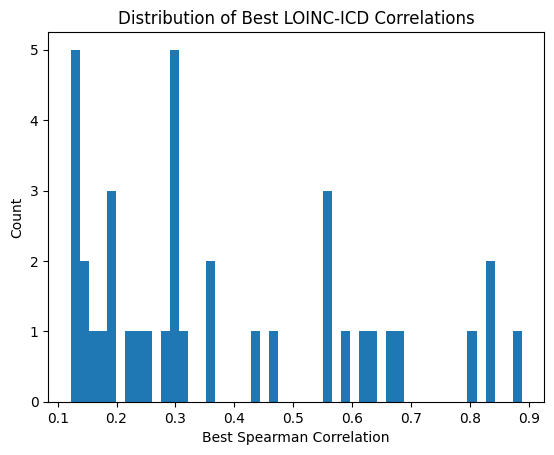

In [ ]:
import matplotlib.pyplot as plt

plt.hist(best_df["rho"], bins=50)
plt.xlabel("Best Spearman Correlation")
plt.ylabel("Count")
plt.title("Distribution of Best LOINC-ICD Correlations")
plt.show()

### Network + Clustering Loinc and ICD10CM Traits

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

all_traits = {**loinc_rank_dict, **icd_rank_dict}
traits = list(all_traits.keys())
n = len(traits)

# initialize correlation matrix
corr_matrix = pd.DataFrame(
    np.zeros((n, n)),
    index=traits,
    columns=traits
)

# calc pairwise Spearman
TOP_N = 500

for i in range(n):
    for j in range(i, n):
        
        t1 = traits[i]
        t2 = traits[j]
        
        s1 = all_traits[t1]
        s2 = all_traits[t2]
        
        # compare base on s1
        top = s1.nsmallest(TOP_N).index
        common_pgs = top.intersection(s2.index)
        
        if len(common_pgs) != 500:
            print("wrong")
            continue

        rho1, _ = spearmanr(s1[common_pgs], s2[common_pgs])

        # compare base on s2
        top = s2.nsmallest(TOP_N).index
        common_pgs = top.intersection(s1.index)
        
        if len(common_pgs) != 500:
            print("wrong")
            continue

        rho2, _ = spearmanr(s1[common_pgs], s2[common_pgs])
        
        corr_matrix.loc[t1, t2] = np.mean([rho1, rho2])
        corr_matrix.loc[t2, t1] = np.mean([rho1, rho2])

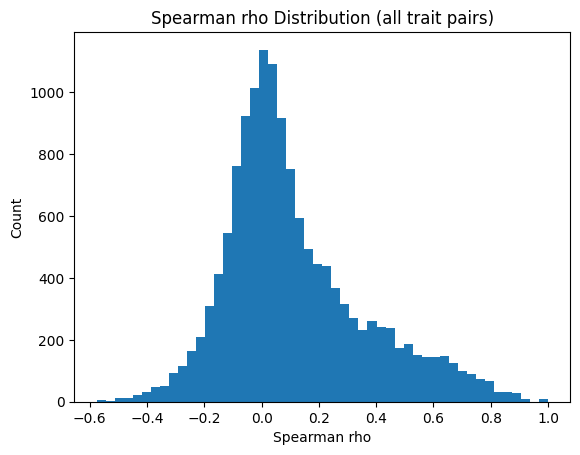

In [4]:
import matplotlib.pyplot as plt

# extract upper triangle element corr_matrix
vals = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
vals = vals.stack()

plt.hist(vals, bins=50)
plt.xlabel("Spearman rho")
plt.title("Spearman rho Distribution (all trait pairs)")
plt.ylabel("Count")
plt.show()

In [8]:
import networkx as nx

threshold = np.percentile(vals, 95)

# construct graph
G = nx.Graph()
for trait in traits:
    G.add_node(trait)

for i in range(n):
    for j in range(i+1, n):
        
        rho = corr_matrix.iloc[i, j]
        
        if pd.notna(rho) and rho > threshold:
            G.add_edge(traits[i], traits[j], weight=rho)

# calculate degress, betweenness, and eigenvector
degree_dict = dict(G.degree())
betweenness = nx.betweenness_centrality(G)
eigenvector = nx.eigenvector_centrality(G)

In [12]:
degree_series = pd.Series(degree_dict).sort_values(ascending=False)
top_degree = degree_series.head(5)
print(top_degree)

N17    43
G47    42
D64    41
U07    41
L03    41
dtype: int64


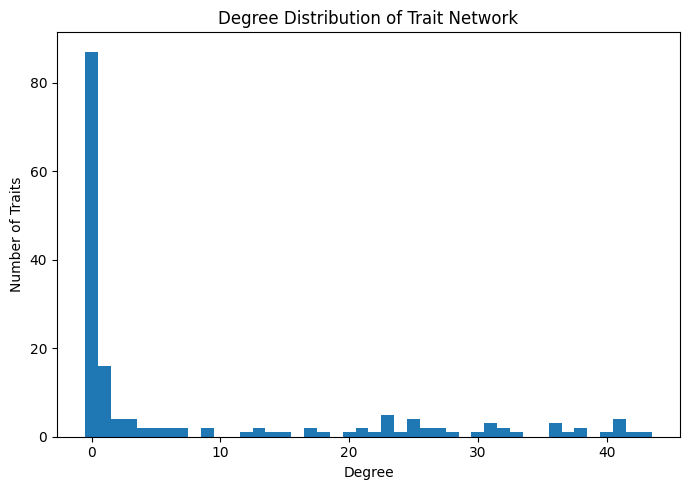

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

degree_series = pd.Series(degree_dict)

plt.figure(figsize=(7,5))

plt.hist(degree_series, bins=range(int(degree_series.min()), int(degree_series.max()) + 2),align="left")
plt.xlabel("Degree")
plt.ylabel("Number of Traits")
plt.title("Degree Distribution of Trait Network")

plt.tight_layout()
plt.show()

In [20]:
bet_series = pd.Series(betweenness).sort_values(ascending=False)
top_degree = bet_series.head(5)
print(top_degree)

R55    0.006281
I50    0.005273
I24    0.004934
N17    0.004355
L03    0.004190
dtype: float64


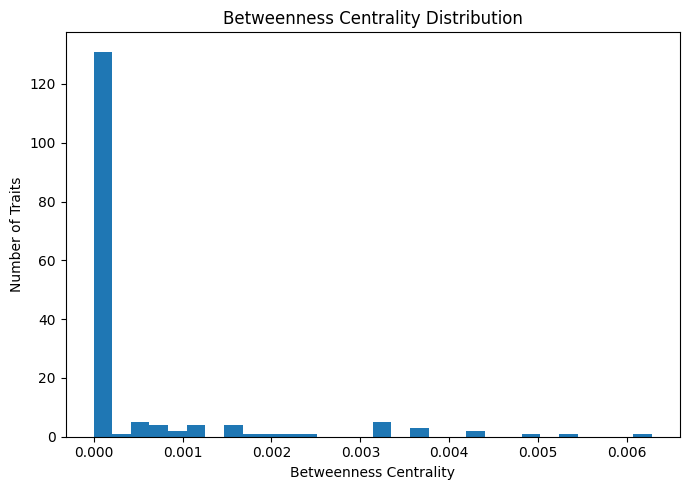

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

bet_series = pd.Series(betweenness)

plt.figure(figsize=(7,5))

plt.hist(bet_series, bins=30)

plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Traits")
plt.title("Betweenness Centrality Distribution")

plt.tight_layout()
plt.show()

In [19]:
bet_series = pd.Series(eigenvector).sort_values(ascending=False)
top_degree = bet_series.head(5)
print(top_degree)

N17    0.204659
G47    0.201902
U07    0.199497
D64    0.198997
I27    0.196754
dtype: float64


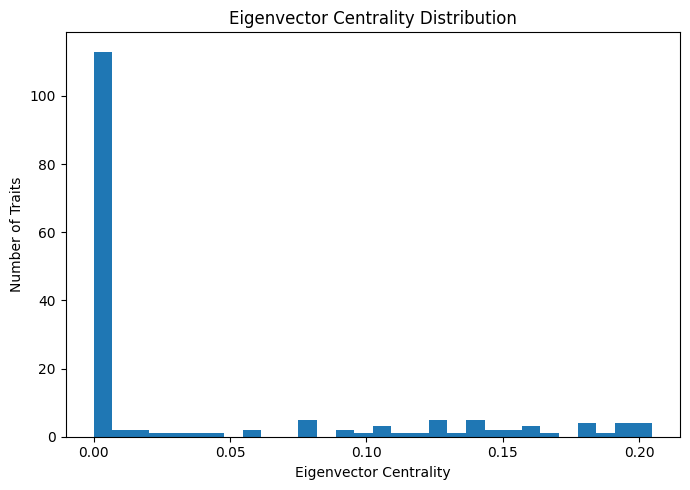

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

eig_series = pd.Series(eigenvector)

plt.figure(figsize=(7,5))
plt.hist(eig_series, bins=30)

plt.xlabel("Eigenvector Centrality")
plt.ylabel("Number of Traits")
plt.title("Eigenvector Centrality Distribution")

plt.tight_layout()
plt.show()

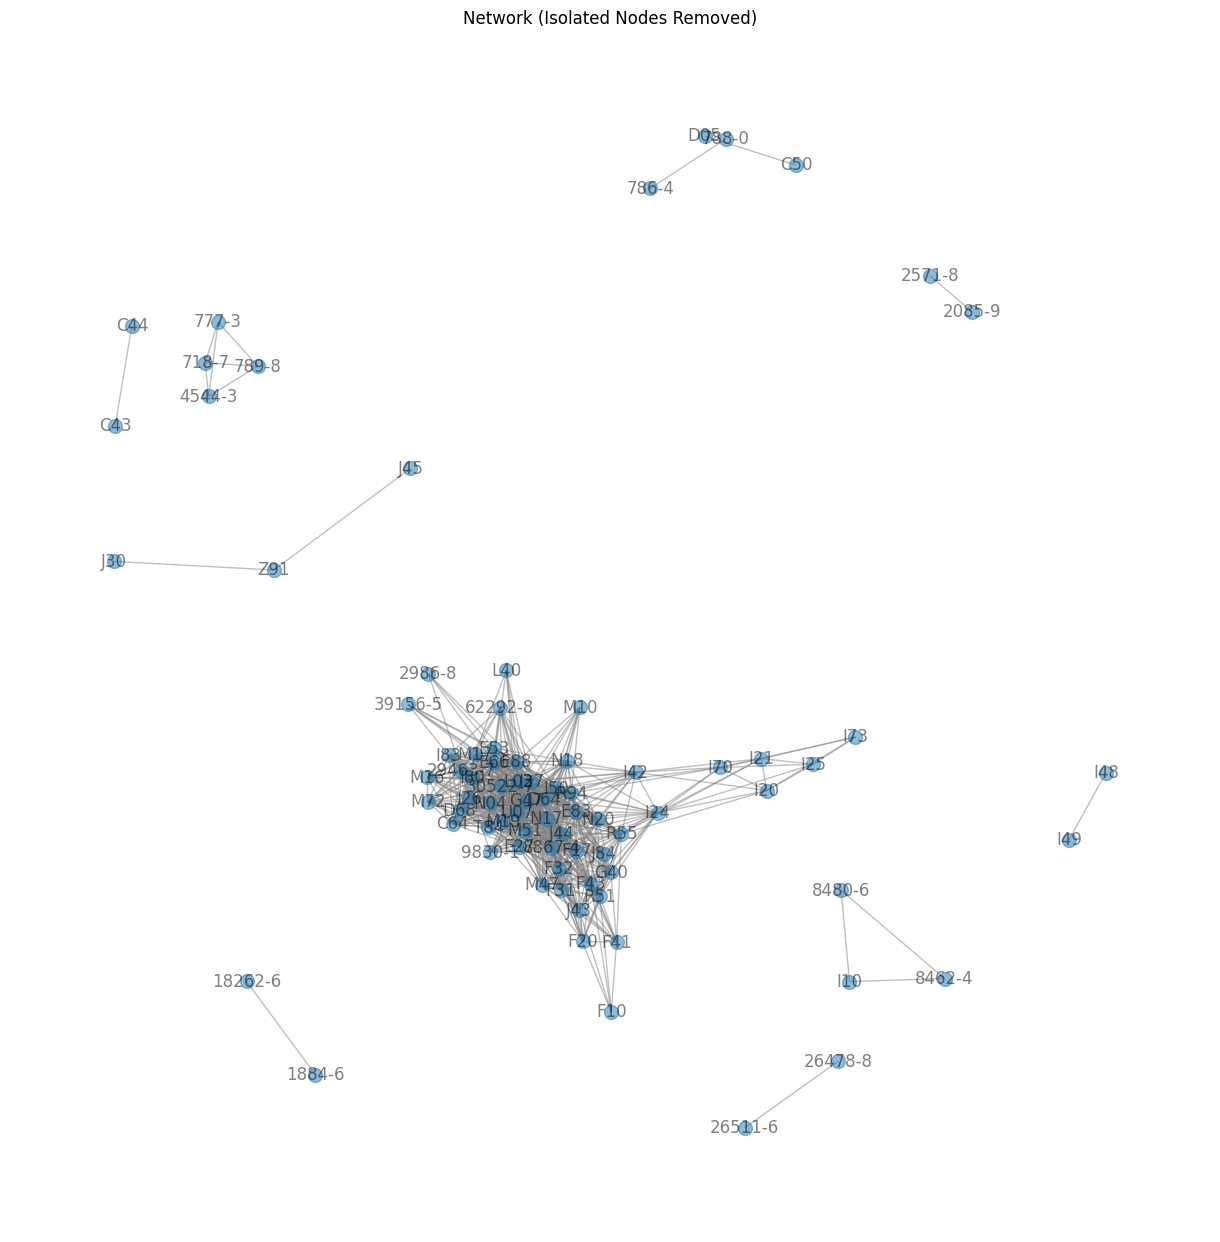

In [85]:
nodes_with_edges = [n for n in G.nodes() if G.degree(n) > 0]

H = G.subgraph(nodes_with_edges)

import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12,12))
pos = nx.spring_layout(
    H, 
    weight='weight',       # 用边权重调整吸引力
    k=0.5,                 # 节点之间的理想距离，增大 k 节点更分散
    iterations=100,        # 迭代次数，多次可改善布局
    seed=42
)

nx.draw(
    H,
    pos,
    node_size=100,
    with_labels=True,
    edge_color="gray",
    alpha=0.5
)

plt.title("Network (Isolated Nodes Removed)")
plt.axis("off")
plt.show()

In [86]:
from networkx.algorithms.community import greedy_modularity_communities
communities = list(greedy_modularity_communities(G, weight='weight'))

partition = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition[node] = i

In [87]:
from collections import defaultdict

# 建立 community -> nodes 映射
comm_dict = defaultdict(list)

for node, cid in partition.items():
    comm_dict[cid].append(node)

# 打印
for cid, nodes in comm_dict.items():
    print(f"\nCommunity {cid} (n={len(nodes)}):")
    print(nodes)


Community 0 (n=29):
['8867-4', 'N18', 'F31', 'R94', 'F41', 'F43', 'F17', 'J43', 'N20', 'I50', 'J84', 'R51', 'N17', 'F10', 'F32', 'I42', 'J44', 'I24', 'I20', 'M47', 'I21', '9830-1', 'F20', 'R55', 'I70', 'E83', 'I73', 'I25', 'G40']

Community 1 (n=28):
['M17', 'I26', 'M72', 'E88', 'C64', 'M10', 'E53', '30522-7', 'L03', 'D68', 'U07', 'E27', 'M19', 'N04', 'I83', 'L40', 'G47', 'I80', 'T84', 'M16', 'I27', '39156-5', 'D64', '62292-8', '29463-7', '2986-8', 'E66', 'M51']

Community 2 (n=4):
['777-3', '4544-3', '718-7', '789-8']

Community 3 (n=3):
['I10', '8462-4', '8480-6']

Community 4 (n=3):
['J45', 'Z91', 'J30']

Community 5 (n=2):
['18262-6', '1884-6']

Community 6 (n=2):
['2085-9', '2571-8']

Community 7 (n=2):
['26511-6', '26478-8']

Community 8 (n=2):
['788-0', '786-4']

Community 9 (n=2):
['C44', 'C43']

Community 10 (n=2):
['D05', 'C50']

Community 11 (n=2):
['I48', 'I49']

Community 12 (n=1):
['10835-7']

Community 13 (n=1):
['1869-7']

Community 14 (n=1):
['2243-4']

Community 15 (

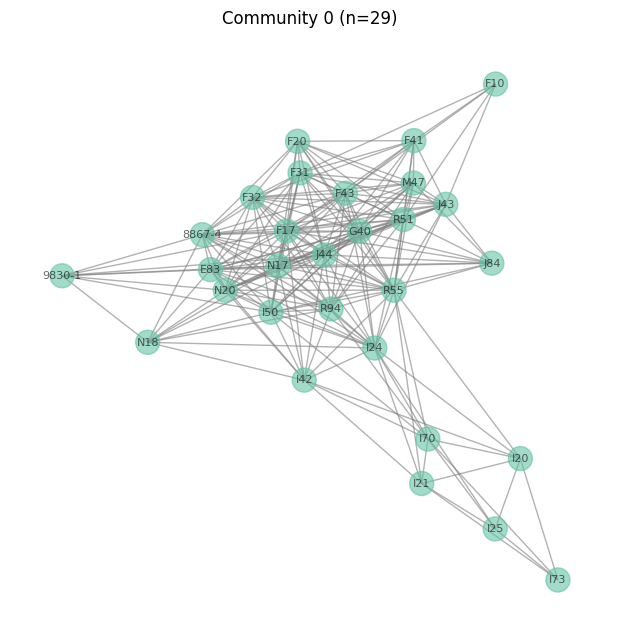

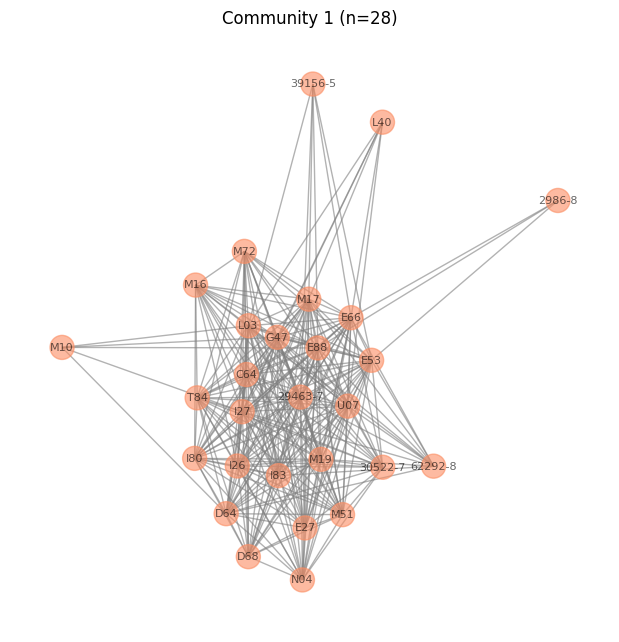

In [88]:
from collections import Counter

# 统计社区大小
community_sizes = Counter(partition.values())

# 只保留节点数 > 5
large_communities = [
    cid for cid, size in community_sizes.items() if size >= 5
]

# 如果只想要前5个最大的
large_communities = sorted(
    large_communities,
    key=lambda x: community_sizes[x],
    reverse=True
)[:5]

colors = plt.cm.Set2(range(len(large_communities)))

for i, cid in enumerate(large_communities):
    
    nodes = [n for n in G.nodes() if partition[n] == cid]
    subG = G.subgraph(nodes)
    
    plt.figure(figsize=(6,6))
    pos = nx.spring_layout(subG, weight='weight', seed=42)
    
    nx.draw(
        subG,
        pos,
        node_color=[colors[i]]*len(nodes),
        node_size=300,
        edge_color="gray",
        alpha=0.6,
        with_labels=True,
        font_size=8
    )
    
    plt.title(f"Community {cid} (n={len(nodes)})")
    plt.axis("off")
    plt.show()

### Every PGS Best Rank across Traits

In [26]:
metainfo_measure = pd.read_csv("../../measurement_preprocess/pgs_metadata_260225.csv")
metainfo_disease = pd.read_csv("../../disease_preprocess/pgs_metadata_260217.csv")
metainfo = pd.concat([metainfo_measure, metainfo_disease], axis=0)
metainfo = metainfo.drop_duplicates(subset="PGS_ID", keep="first")
metainfo = metainfo.set_index("PGS_ID")
metainfo["date_release"] = pd.to_datetime(metainfo["date_release"], errors="coerce")

In [27]:
def ranking_row_to_series(row, excluded_pgs):
    pgs = row.dropna().astype(str)
    pgs = pgs.str.split("__").str[-1]

    # exclude pgs outside the range
    pgs = pgs[~pgs.isin(excluded_pgs)]

    ranks = np.arange(1, len(pgs) + 1)
    return pd.Series(ranks, index=pgs.values)

In [78]:
post2024_pgs = metainfo.loc[
    metainfo["date_release"] >= "2026-01-01"
].index
excluded_pgs = set(post2024_pgs)

loinc_rank_dict = {
    trait: ranking_row_to_series(row, excluded_pgs)
    for trait, row in loinc_rank_matrix.iterrows()
}

icd_rank_dict = {
    trait: ranking_row_to_series(row, excluded_pgs)
    for trait, row in icd_rank_matrix.iterrows()
}
combined_rank_dict = {**loinc_rank_dict, **icd_rank_dict}
rank_df = pd.DataFrame(combined_rank_dict).T
best_rank = rank_df.min(axis=0)
matched_ids = best_rank.index.intersection(metainfo.index)
best_rank = best_rank.loc[matched_ids]
rank_counts = best_rank.value_counts().sort_index()
mean_rank = best_rank.mean()

# only filter PGS release before 2020
pgs_ids = best_rank.index
release_date =metainfo.loc[pgs_ids, "date_release"]
mask = release_date < "2022-01-01"
rank_count_2022 = (best_rank[mask].value_counts().sort_index())
mean_rank_2022 = best_rank[mask].mean()

# only filter PGS release within one year
pgs_ids = best_rank.index
release_date =metainfo.loc[pgs_ids, "date_release"]
mask = release_date > "2025-01-01"
rank_count_oneyear = (best_rank[mask].value_counts().sort_index())
mean_rank_oneyear = best_rank[mask].mean()

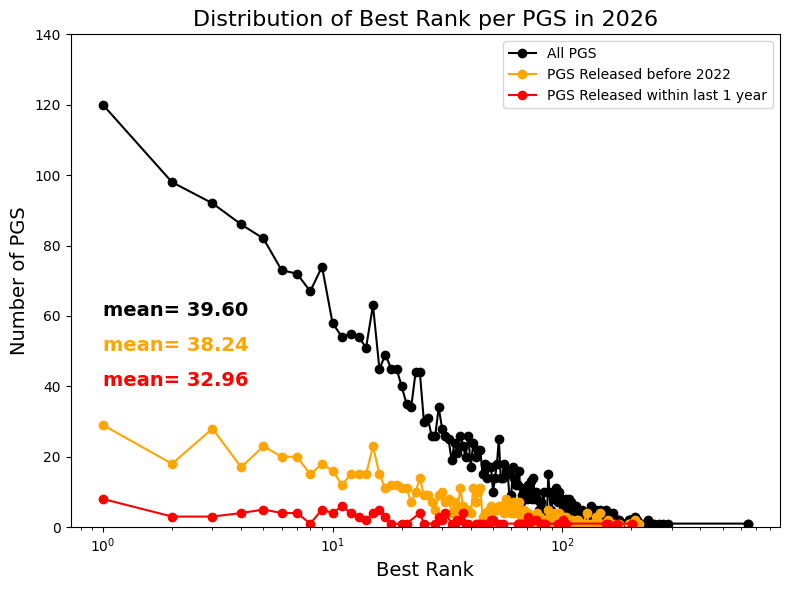

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(rank_counts.index, rank_counts.values, marker="o", label="All PGS", color="black")
plt.plot(rank_count_2022.index, rank_count_2022.values, marker="o", label="PGS Released before 2022", color="orange")
plt.plot(rank_count_oneyear.index, rank_count_oneyear.values, marker="o", label="PGS Released within last 1 year", color="red")
plt.text(1, 60, f"mean= {mean_rank:.2f}", fontsize=14, color="black", fontweight="bold")
plt.text(1, 50, f"mean= {mean_rank_2022:.2f}", fontsize=14, color="orange", fontweight="bold")
plt.text(1, 40, f"mean= {mean_rank_oneyear:.2f}", fontsize=14, color="red", fontweight="bold")

plt.xlabel("Best Rank", fontsize=14)
plt.ylabel("Number of PGS", fontsize=14)
plt.title("Distribution of Best Rank per PGS in 2026", fontsize=16)
plt.xscale("log") 
plt.legend()
plt.ylim(0, 140)

plt.tight_layout()
plt.show()

### PGS Best Rank Across Traits

In [95]:
def ranking_row_to_series(row):
    pgs = row.dropna().astype(str)

    split = pgs.str.split("__")

    target_trait = split.str[0].str.split("+")  
    pgs_id = split.str[1]

    ranks = np.arange(1, len(pgs) + 1)

    df = pd.DataFrame({
        "PGS_ID": pgs_id.values,
        "target_trait": target_trait.values, 
        "rank": ranks
    })

    return df.set_index("PGS_ID")

In [96]:
loinc_rank_dict = {
    trait: ranking_row_to_series(row)
    for trait, row in loinc_rank_matrix.iterrows()
}
icd_rank_dict = {
    trait: ranking_row_to_series(row)
    for trait, row in icd_rank_matrix.iterrows()
}
combined_rank_dict = {**loinc_rank_dict, **icd_rank_dict}
rank_df = pd.concat(combined_rank_dict, names=["evaluated_trait"])

In [97]:
best = rank_df.loc[
    rank_df.groupby("PGS_ID")["rank"].idxmin()
]
evaluated = best.index.get_level_values("evaluated_trait")

match = [
    eval_trait in targets
    for eval_trait, targets in zip(evaluated, best["target_trait"])
]

match = pd.Series(match, index=best.index)
match_rate = match.mean()

In [98]:
n_traits = rank_df.index.get_level_values("evaluated_trait").nunique()
avg_target_count = best["target_trait"].apply(len).mean()
expected = avg_target_count / n_traits

In [99]:
enrichment = match_rate / expected
print(enrichment)

27.332722273143908


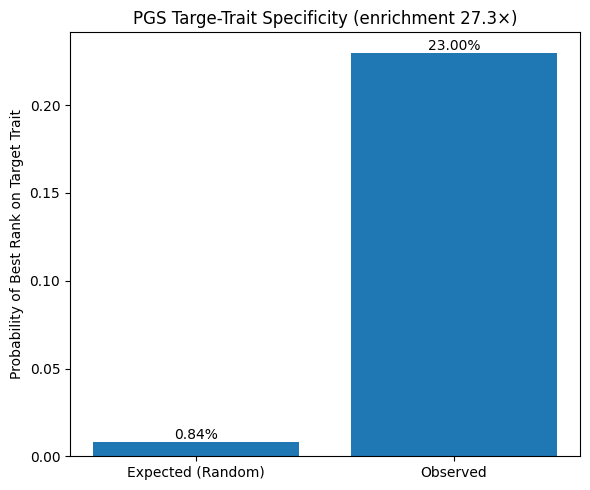

In [101]:
import matplotlib.pyplot as plt

observed = match_rate
expected = expected  # 你算出来的 baseline

plt.figure(figsize=(6,5))

plt.bar(["Expected (Random)", "Observed"], 
        [expected, observed])

plt.ylabel("Probability of Best Rank on Target Trait")
plt.title("PGS Targe-Trait Specificity (enrichment 27.3×)")

plt.text(1, observed, f"{observed:.2%}", ha='center', va='bottom')
plt.text(0, expected, f"{expected:.2%}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Pleiotropy Score

In [108]:
from collections import Counter

pleiotropy_counter = Counter()

for trait in loinc_rank_matrix.index:
    top10 = loinc_rank_matrix.loc[trait].dropna().values[:10]
    for pgs in top10:
        pgs_id = pgs.split("__")[1]   # 如果格式是 trait__PGSID
        pleiotropy_counter[pgs_id] += 1

for trait in icd_rank_matrix.index:
    top10 = icd_rank_matrix.loc[trait].dropna().values[:10]
    for pgs in top10:
        pgs_id = pgs.split("__")[1]   # 如果格式是 trait__PGSID
        pleiotropy_counter[pgs_id] += 1

pleiotropy_score = pd.Series(pleiotropy_counter)

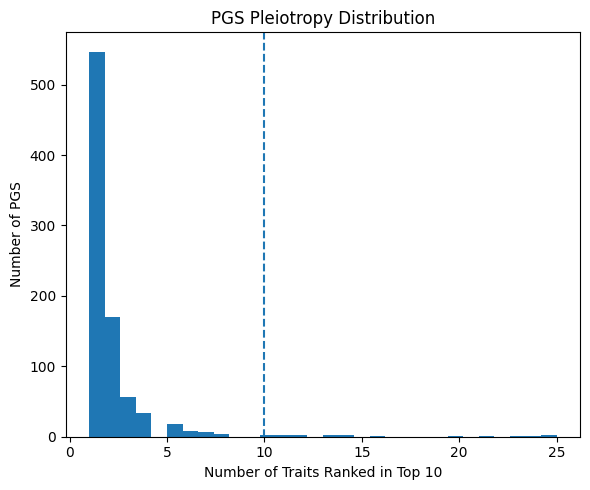

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.hist(pleiotropy_score, bins=30)
plt.axvline(10, linestyle="--")

plt.xlabel("Number of Traits Ranked in Top 10")
plt.ylabel("Number of PGS")
plt.title("PGS Pleiotropy Distribution")

plt.tight_layout()
plt.show()

In [111]:
high_pleio = pleiotropy_score[pleiotropy_score > 10]

print(high_pleio)

PGS005199    20
PGS005203    24
PGS003525    23
PGS004735    16
PGS002161    25
PGS004536    11
PGS004798    13
PGS002679    12
PGS002313    14
PGS001943    14
PGS004745    12
PGS004760    25
PGS004819    21
PGS000907    13
PGS003333    11
dtype: int64
